In [21]:
import kagglehub
import os

# Download FER-2013 dataset
path = kagglehub.dataset_download("deadskull7/fer2013")
print("Dataset downloaded to path:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Dataset downloaded to path: /kaggle/input/fer2013


In [22]:
import pandas as pd
import numpy as np
from tensorflow.keras.utils import to_categorical

# Find the csv file path automatically
csv_path = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            csv_path = os.path.join(root, file)

print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)

def prepare_data(data):
    image_array = data['pixels'].tolist()
    image_faces = []
    for row in image_array:
        face = [int(pixel) for pixel in row.split()]
        face = np.array(face).reshape(48, 48)
        image_faces.append(face)

    image_faces = np.array(image_faces)
    image_faces = image_faces / 255.0  # Normalize pixel values to [0, 1]
    image_faces = np.expand_dims(image_faces, -1)  # Shape: (samples, 48, 48, 1)

    labels = to_categorical(data['emotion'], num_classes=7)
    return image_faces, labels

# Split into Training and Public Test sets based on FER-2013 metadata
train_data = df[df['Usage'] == 'Training']
test_data = df[df['Usage'] == 'PublicTest']

X_train, y_train = prepare_data(train_data)
X_test, y_test = prepare_data(test_data)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Loading dataset from: /kaggle/input/fer2013/fer2013.csv
Training data shape: (28709, 48, 48, 1)
Testing data shape: (3589, 48, 48, 1)


NameError: name 'preprocess_data' is not defined

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,145,351 (4.37 MB)

 Trainable params: 1,145,351 (4.37 MB)

 Non-trainable params: 0 (0.00 B)

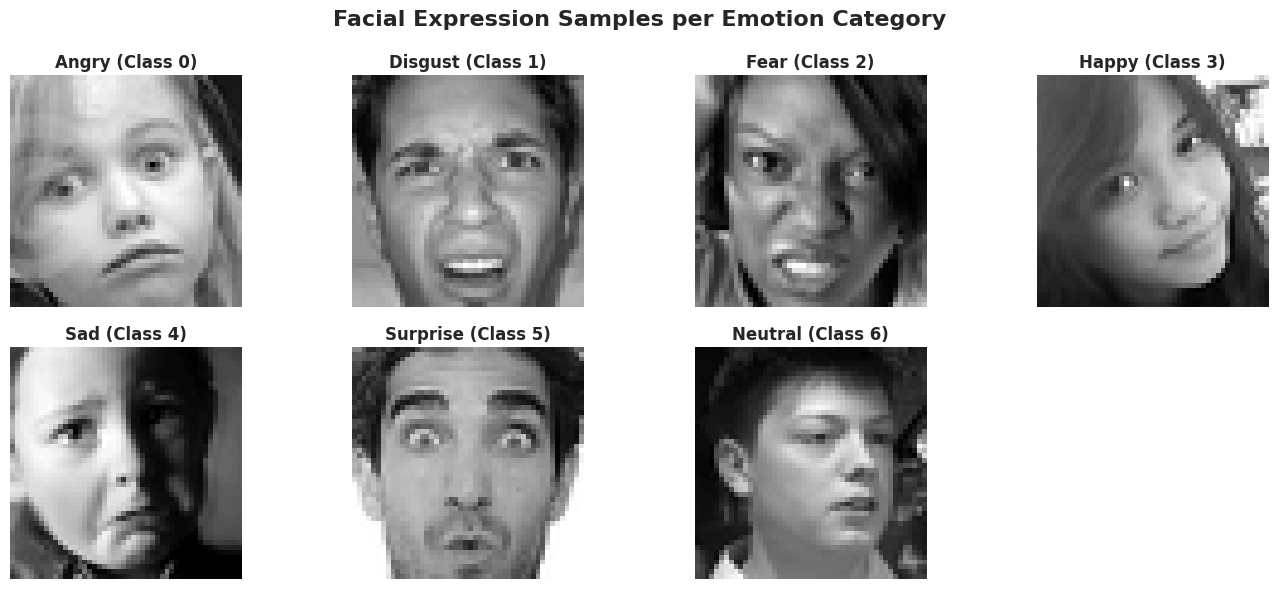

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Define emotion mapping labels
emotion_mapping = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral",
}

plt.figure(figsize=(14, 6))
plt.suptitle(
    "Facial Expression Samples per Emotion Category",
    fontsize=16,
    fontweight="bold",
)

# Loop through each emotion and plot a random sample
for idx, (label_num, label_name) in enumerate(emotion_mapping.items()):
  class_samples = df[df["emotion"] == label_num]

  if not class_samples.empty:
    sample_row = class_samples.sample(1)
    pixel_string = sample_row["pixels"].values[0]

    # Convert space-separated pixel string to a 48x48 numpy array
    img_pixels = np.array(pixel_string.split(" "), dtype="float32")
    img_reshaped = img_pixels.reshape(48, 48)

    plt.subplot(2, 4, idx + 1)
    plt.imshow(img_reshaped, cmap="gray")
    plt.title(
        f"{label_name} (Class {label_num})", fontsize=12, fontweight="bold"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint, EarlyStopping

# Setup callbacks to save metrics and best weights automatically
csv_logger = CSVLogger('training_log.csv', append=False)
checkpoint = ModelCheckpoint('emotion_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=64,
    callbacks=[csv_logger, checkpoint, early_stop],
    verbose=1
)

print("Training complete! Model saved as 'emotion_model.h5'.")

Epoch 1/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.2498 - loss: 1.8177
Epoch 1: val_accuracy improved from None to 0.39147, saving model to emotion_model.h5



Epoch 1: finished saving model to emotion_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 104s 228ms/step - accuracy: 0.2866 - loss: 1.7577 - val_accuracy: 0.3915 - val_loss: 1.5957
Epoch 2/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.3910 - loss: 1.5669
Epoch 2: val_accuracy improved from 0.39147 to 0.46364, saving model to emotion_model.h5



Epoch 2: finished saving model to emotion_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 141s 226ms/step - accuracy: 0.4061 - loss: 1.5324 - val_accuracy: 0.4636 - val_loss: 1.3971
Epoch 3/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.4486 - loss: 1.4268
Epoch 3: val_accuracy improved from 0.46364 to 0.49930, saving model to emotion_model.h5



Epoch 3: finished saving model to emotion_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 144s 230ms/step - accuracy: 0.4550 - loss: 1.4125 - val_accuracy: 0.4993 - val_loss: 1.3200
Epoch 4/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.4890 - loss: 1.3355
Epoch 4: val_accuracy improved from 0.49930 to 0.50627, saving model to emotion_model.h5



Epoch 4: finished saving model to emotion_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 140s 225ms/step - accuracy: 0.4871 - loss: 1.3363 - val_accuracy: 0.5063 - val_loss: 1.2705
Epoch 5/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.5126 - loss: 1.2750
Epoch 5: val_accuracy improved from 0.50627 to 0.53580, saving model to emotion_model.h5


...


Epoch 15: finished saving model to emotion_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 99s 221ms/step - accuracy: 0.6141 - loss: 1.0277 - val_accuracy: 0.5915 - val_loss: 1.1064
Epoch 16/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.6286 - loss: 0.9945
Epoch 16: val_accuracy improved from 0.59153 to 0.59320, saving model to emotion_model.h5



Epoch 16: finished saving model to emotion_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 101s 225ms/step - accuracy: 0.6225 - loss: 1.0100 - val_accuracy: 0.5932 - val_loss: 1.1027
Epoch 17/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.6345 - loss: 0.9829
Epoch 17: val_accuracy did not improve from 0.59320
449/449 ━━━━━━━━━━━━━━━━━━━━ 100s 222ms/step - accuracy: 0.6309 - loss: 0.9882 - val_accuracy: 0.5932 - val_loss: 1.1025
Epoch 18/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.6384 - loss: 0.9679
Epoch 18: val_accuracy improved from 0.59320 to 0.59766, saving model to emotion_model.h5



Epoch 18: finished saving model to emotion_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 101s 225ms/step - accuracy: 0.6350 - loss: 0.9715 - val_accuracy: 0.5977 - val_loss: 1.0936
Epoch 19/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.6401 - loss: 0.9498
Epoch 19: val_accuracy did not improve from 0.59766
449/449 ━━━━━━━━━━━━━━━━━━━━ 99s 221ms/step - accuracy: 0.6395 - loss: 0.9586 - val_accuracy: 0.5943 - val_loss: 1.0958
Epoch 20/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.6538 - loss: 0.9233
Epoch 20: val_accuracy did not improve from 0.59766
449/449 ━━━━━━━━━━━━━━━━━━━━ 145s 229ms/step - accuracy: 0.6500 - loss: 0.9379 - val_accuracy: 0.5943 - val_loss: 1.1009
Epoch 21/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.6614 - loss: 0.9074
Epoch 21: val_accuracy did not improve from 0.59766
449/449 ━━━━━━━━━━━━━━━━━━━━ 141s 228ms/step - accuracy: 0.6560 - loss: 0.9234 - val_accuracy: 0.5954 - val_loss: 1.0982
Epoch 22/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 


Epoch 22: finished saving model to emotion_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 99s 221ms/step - accuracy: 0.6538 - loss: 0.9254 - val_accuracy: 0.6077 - val_loss: 1.0905
Epoch 23/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.6634 - loss: 0.8962
Epoch 23: val_accuracy did not improve from 0.60769
449/449 ━━━━━━━━━━━━━━━━━━━━ 142s 221ms/step - accuracy: 0.6594 - loss: 0.9037 - val_accuracy: 0.5940 - val_loss: 1.0917
Epoch 24/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.6723 - loss: 0.8748
Epoch 24: val_accuracy did not improve from 0.60769
449/449 ━━━━━━━━━━━━━━━━━━━━ 101s 225ms/step - accuracy: 0.6690 - loss: 0.8839 - val_accuracy: 0.6004 - val_loss: 1.0958
Epoch 25/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.6775 - loss: 0.8589
Epoch 25: val_accuracy improved from 0.60769 to 0.60797, saving model to emotion_model.h5



Epoch 25: finished saving model to emotion_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 142s 225ms/step - accuracy: 0.6747 - loss: 0.8748 - val_accuracy: 0.6080 - val_loss: 1.0915
Restoring model weights from the end of the best epoch: 22.
Training complete! Model saved as 'emotion_model.h5'.


In [28]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

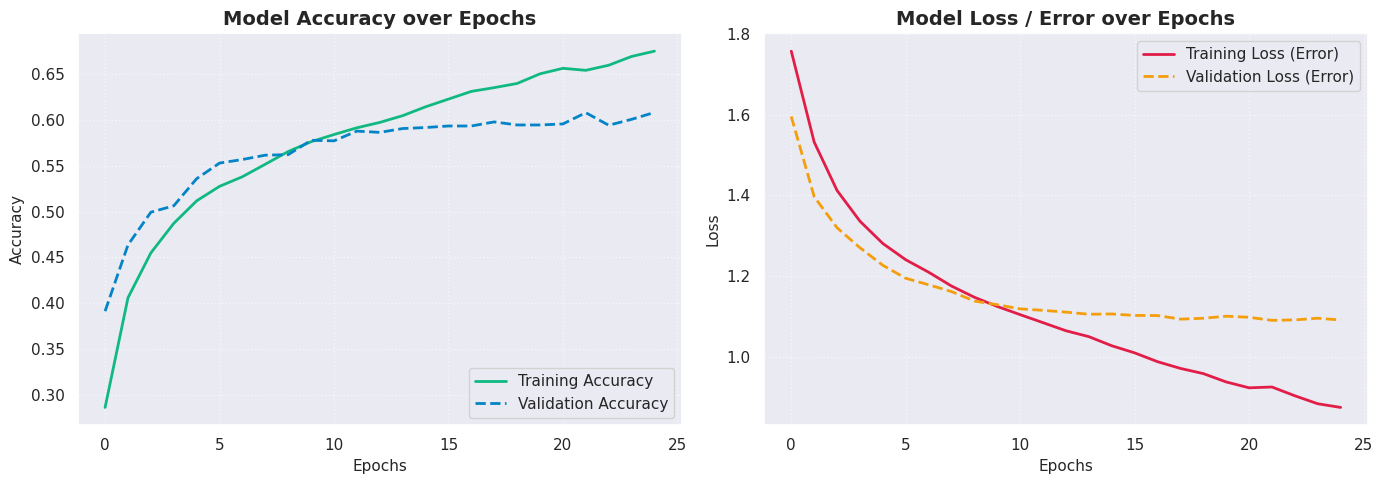

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Pull history from memory or fallback to the saved CSV log file if needed
if 'history' in locals() and hasattr(history, 'history'):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
elif os.path.exists('training_log.csv'):
    log_df = pd.read_csv('training_log.csv')
    acc = log_df['accuracy']
    val_acc = log_df['val_accuracy']
    loss = log_df['loss']
    val_loss = log_df['val_loss']
else:
    print("Training log not found. Please run the training cell first.")
    acc, val_acc, loss, val_loss = [], [], [], []

if len(acc) > 0:
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # 1. Accuracy Graph
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#10b981', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#0284c7', linewidth=2, linestyle='--')
    plt.title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=11)
    plt.ylabel('Accuracy', fontsize=11)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)

    # 2. Loss / Error Graph
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss (Error)', color='#e11d48', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss (Error)', color='#f59e0b', linewidth=2, linestyle='--')
    plt.title('Model Loss / Error over Epochs', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=11)
    plt.ylabel('Loss', fontsize=11)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

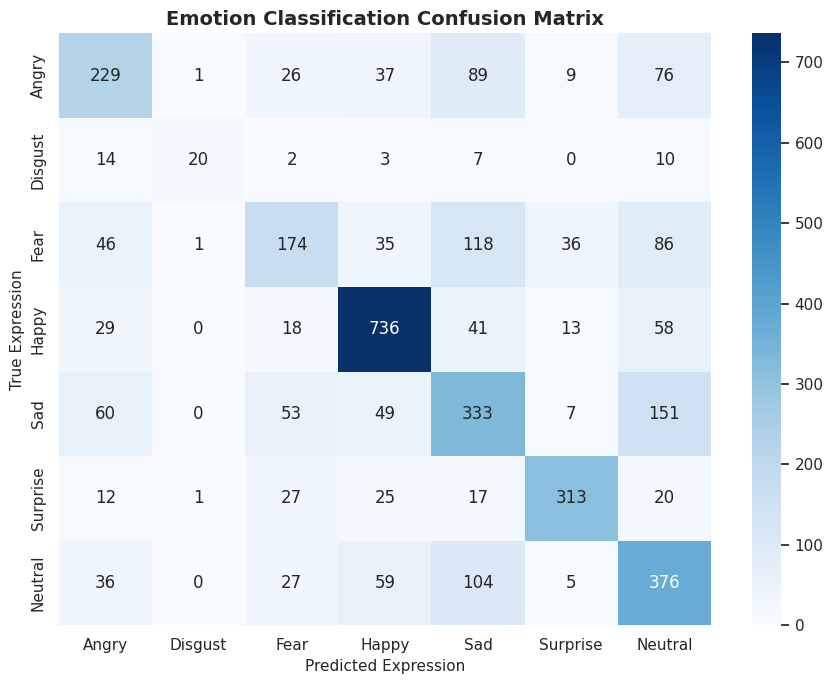

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions if not already generated
y_pred_probs = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)
plt.title('Emotion Classification Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Expression', fontsize=11)
plt.ylabel('True Expression', fontsize=11)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3997/406217910.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=emotion_labels, y=f1_scores, palette='viridis')


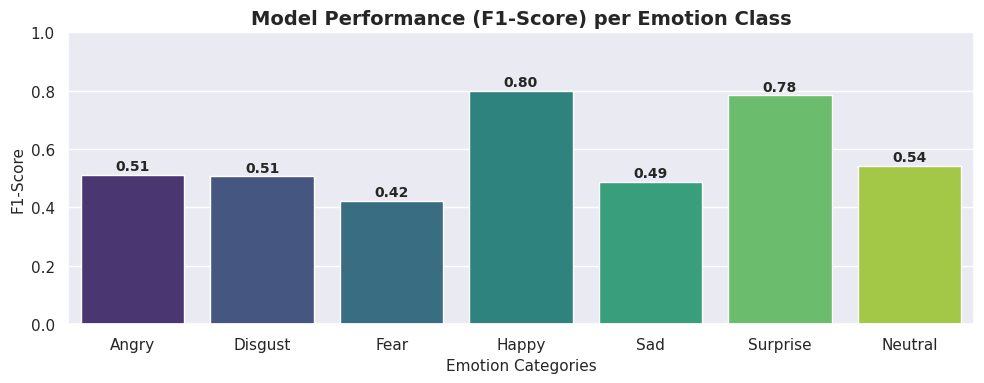

In [32]:
from sklearn.metrics import classification_report

# Generate classification report as a dictionary
report = classification_report(y_true_classes, y_pred_classes, target_names=emotion_labels, output_dict=True)
f1_scores = [report[c]['f1-score'] for c in emotion_labels]

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=emotion_labels, y=f1_scores, palette='viridis')
plt.title('Model Performance (F1-Score) per Emotion Class', fontsize=14, fontweight='bold')
plt.xlabel('Emotion Categories', fontsize=11)
plt.ylabel('F1-Score', fontsize=11)
plt.ylim(0, 1.0)

# Add score labels on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

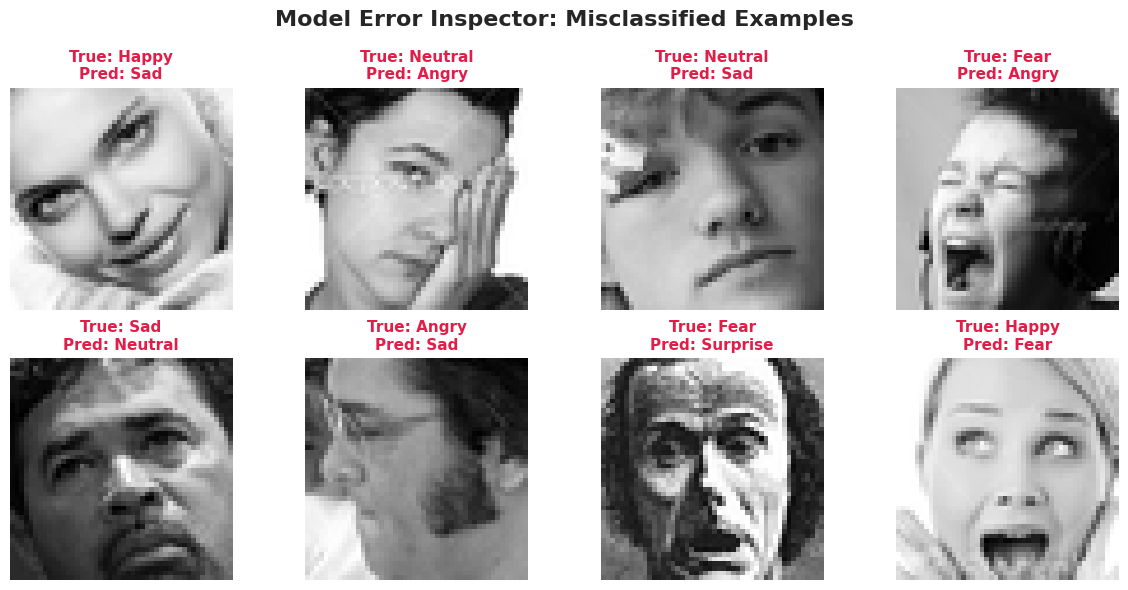

In [33]:
# Find indices where prediction does not match reality
incorrect_indices = np.where(y_pred_classes != y_true_classes)[0]

plt.figure(figsize=(12, 6))
plt.suptitle('Model Error Inspector: Misclassified Examples', fontsize=16, fontweight='bold')

# Pick up to 8 random misclassified samples
sample_indices = np.random.choice(incorrect_indices, min(8, len(incorrect_indices)), replace=False)

for i, idx in enumerate(sample_indices):
    plt.subplot(2, 4, i + 1)
    # Reshape and display the 48x48 grayscale image
    plt.imshow(X_test[idx].reshape(48, 48), cmap='gray')

    true_label = emotion_labels[y_true_classes[idx]]
    pred_label = emotion_labels[y_pred_classes[idx]]

    plt.title(f"True: {true_label}\nPred: {pred_label}", color='#e11d48', fontsize=11, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [30]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

print("Running predictions on the test dataset...")

# Generate probability predictions for X_test
y_pred_probs = model.predict(X_test, verbose=1)

# Convert probabilities and one-hot encoded true labels back to class indices (0-6)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Calculate accuracy
test_accuracy = accuracy_score(y_true_classes, y_pred_classes)

print("\n===============================")
print("      TEST SET PREDICTION")
print("===============================")
print(f"🎯 Test Accuracy: {test_accuracy * 100:.2f}%")
print("===============================\n")

# Emotion mapping labels for reference
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Print detailed classification report (Precision, Recall, F1-Score per emotion)
print("Detailed Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=emotion_labels))

Running predictions on the test dataset...
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step

      TEST SET PREDICTION
🎯 Test Accuracy: 60.77%

Detailed Classification Report:
              precision    recall  f1-score   support

       Angry       0.54      0.49      0.51       467
     Disgust       0.87      0.36      0.51        56
        Fear       0.53      0.35      0.42       496
       Happy       0.78      0.82      0.80       895
         Sad       0.47      0.51      0.49       653
    Surprise       0.82      0.75      0.78       415
     Neutral       0.48      0.62      0.54       607

    accuracy                           0.61      3589
   macro avg       0.64      0.56      0.58      3589
weighted avg       0.61      0.61      0.60      3589

